# Gaussian Naive Bayes - Heart Disease

Explores a tuned Gaussian Naive Bayes classifier on the cleaned splits.

**Method.** Hyperparameters are tuned with stratified 5-fold `GridSearchCV` on the
**training** set; the tuned model is evaluated on the **validation** set. The
**test** set is deliberately left untouched here - it is reserved for the final
cross-model comparison notebook, so the hold-out is spent only once.

GaussianNB models each feature as an independent per-class Gaussian and
combines them with Bayes' rule. The one-hot/binary columns clearly violate the
Gaussian assumption, but NB often ranks well anyway - its probabilities are
less trustworthy than its rankings (see the calibration section). No scaler is
added to the pipeline: the per-feature Gaussians adapt to each feature's
location and scale on their own.

In [1]:
import sys
from pathlib import Path

# Make the scripts/ helpers importable from notebooks/.
sys.path.insert(0, str(Path.cwd().parent / "scripts"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    roc_auc_score, recall_score, precision_score, f1_score, accuracy_score,
    confusion_matrix, roc_curve, ConfusionMatrixDisplay,
)

from dataset import load_splits, get_xy
from train_models import build_pipeline, MODELS, CV

MODEL_NAME = "naive_bayes"

## Load data

In [2]:
train, val, test = load_splits()
X_train, y_train = get_xy(train)
X_val, y_val = get_xy(val)

print(f"train {X_train.shape}  val {X_val.shape}  (test held back)")
print(f"train disease rate {y_train.mean():.3f}  val {y_val.mean():.3f}")

train (552, 15)  val (184, 15)  (test held back)
train disease rate 0.553  val 0.554


## Tune hyperparameters (train, 5-fold CV)

The estimator and grid come straight from the `MODELS` registry in
`train_models.py`, so the notebook and the batch script stay in sync.

In [3]:
cfg = MODELS[MODEL_NAME]
pipe = build_pipeline(cfg["estimator"], cfg["needs_scaling"], list(X_train.columns))
search = GridSearchCV(pipe, cfg["grid"], cv=CV, scoring="roc_auc", n_jobs=-1)
search.fit(X_train, y_train)

best = search.best_estimator_
print("best params:", search.best_params_)
print(f"cv roc-auc: {search.best_score_:.3f}")

best params: {'model__var_smoothing': 1e-05}
cv roc-auc: 0.871


## Validation metrics

In [4]:
proba = best.predict_proba(X_val)[:, 1]
pred = best.predict(X_val)

metrics = {
    "roc_auc": roc_auc_score(y_val, proba),
    "recall": recall_score(y_val, pred),
    "precision": precision_score(y_val, pred),
    "f1": f1_score(y_val, pred),
    "accuracy": accuracy_score(y_val, pred),
}
pd.Series(metrics, name=MODEL_NAME).round(3)

roc_auc      0.859
recall       0.833
precision    0.794
f1           0.813
accuracy     0.788
Name: naive_bayes, dtype: float64

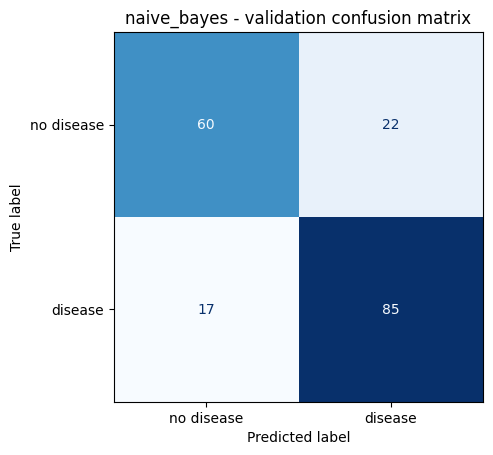

In [5]:
ConfusionMatrixDisplay(
    confusion_matrix(y_val, pred), display_labels=["no disease", "disease"]
).plot(cmap="Blues", colorbar=False)
plt.title(f"{MODEL_NAME} - validation confusion matrix")
plt.show()

## Hyperparameter comparison

`var_smoothing` adds a fraction of the largest feature variance to every
feature's variance, flattening the per-feature Gaussians - a numerical guard
that doubles as light regularization. The grid is tiny, so every configuration
is shown.

In [6]:
cv_results = pd.DataFrame(search.cv_results_)

nb_grid = cv_results[
    ["param_model__var_smoothing", "mean_test_score", "std_test_score"]
].copy()
nb_grid = nb_grid.rename(columns={
    "param_model__var_smoothing": "var_smoothing",
    "mean_test_score": "cv_roc_auc",
    "std_test_score": "cv_std",
})
nb_grid.sort_values("cv_roc_auc", ascending=False).round({"cv_roc_auc": 3, "cv_std": 3})

,var_smoothing,cv_roc_auc,cv_std
3,1.000000e-05,0.871,0.027
2,1.000000e-07,0.865,0.033
1,1.000000e-09,0.865,0.033
0,1.000000e-11,0.865,0.033


## How performance varies with `var_smoothing`

Sweeping a much wider, log-spaced range than the grid shows how sensitive the
model actually is. Tiny values leave the fitted variances untouched; large
values flatten every Gaussian toward the same width, washing out the
per-feature evidence.

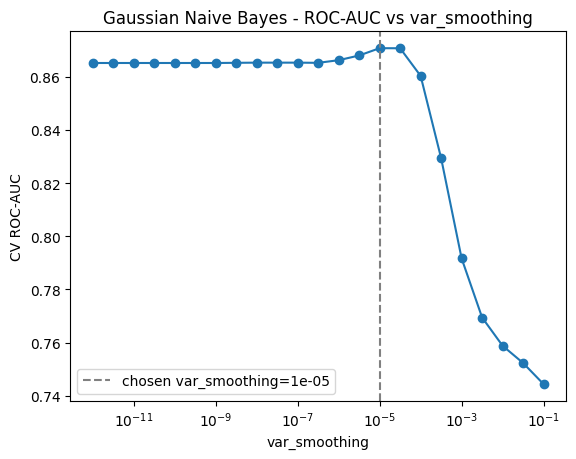

In [7]:
smoothings = np.logspace(-12, -1, 23)
scores = []
for vs in smoothings:
    trial = build_pipeline(cfg["estimator"], cfg["needs_scaling"], list(X_train.columns))
    trial.set_params(model__var_smoothing=vs)
    scores.append(cross_val_score(trial, X_train, y_train, cv=CV, scoring="roc_auc").mean())

chosen = search.best_params_["model__var_smoothing"]
plt.semilogx(smoothings, scores, marker="o")
plt.axvline(chosen, color="gray", ls="--", label=f"chosen var_smoothing={chosen:g}")
plt.xlabel("var_smoothing")
plt.ylabel("CV ROC-AUC")
plt.title("Gaussian Naive Bayes - ROC-AUC vs var_smoothing")
plt.legend()
plt.show()

## Probability calibration

Naive Bayes multiplies many per-feature likelihoods that are treated as
independent when they are not, so its posteriors are pushed toward 0 and 1 -
overconfident even when the ranking (ROC-AUC) is fine. The reliability curve
bins the validation predictions and compares predicted probability with the
observed disease rate in each bin; the histogram shows the pile-up at the
extremes. ROC-AUC is unaffected, but any decision threshold chosen on these
probabilities inherits the distortion.

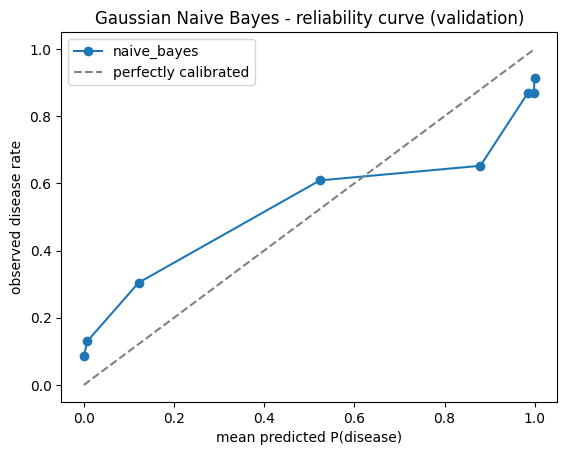

In [8]:
frac_pos, mean_pred = calibration_curve(y_val, proba, n_bins=8, strategy="quantile")

plt.plot(mean_pred, frac_pos, marker="o", label=MODEL_NAME)
plt.plot([0, 1], [0, 1], ls="--", color="gray", label="perfectly calibrated")
plt.xlabel("mean predicted P(disease)")
plt.ylabel("observed disease rate")
plt.title("Gaussian Naive Bayes - reliability curve (validation)")
plt.legend()
plt.show()

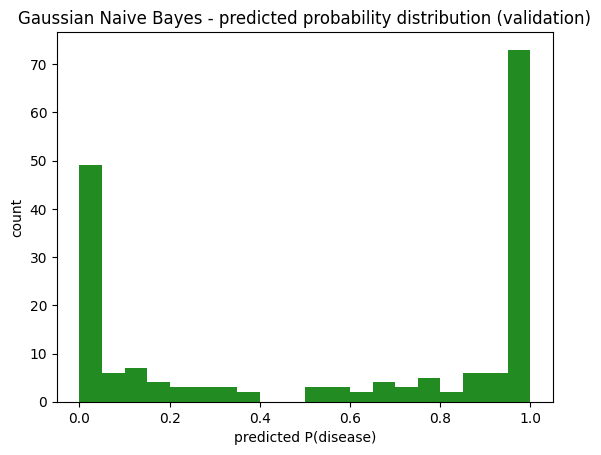

In [9]:
plt.hist(proba, bins=20, color="forestgreen")
plt.xlabel("predicted P(disease)")
plt.ylabel("count")
plt.title("Gaussian Naive Bayes - predicted probability distribution (validation)")
plt.show()

## ROC curve (validation)

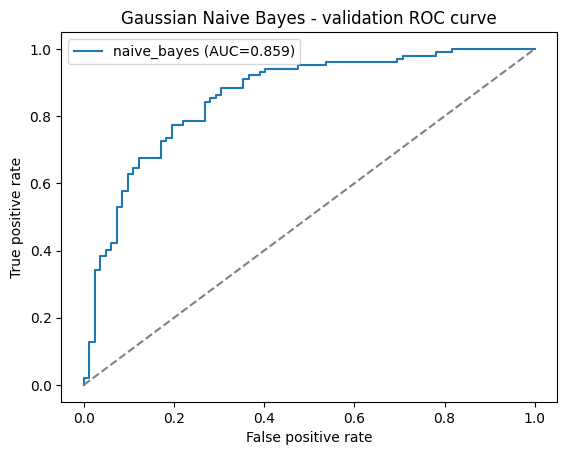

In [10]:
fpr, tpr, _ = roc_curve(y_val, proba)
plt.plot(fpr, tpr, label=f"{MODEL_NAME} (AUC={metrics['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], ls="--", color="gray")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Gaussian Naive Bayes - validation ROC curve")
plt.legend()
plt.show()

## Notes

- Test set intentionally not touched - see the comparison notebook for the
  single final test evaluation of the selected model.
- If calibrated probabilities were ever needed (e.g. risk scores), the model
  could be wrapped in `CalibratedClassifierCV`; for the ROC-AUC/recall
  comparison in this project the raw scores suffice.
- This notebook is Gaussian Naive Bayes specific. To explore another model,
  start from the shared template and swap in a model-appropriate diagnostic.